# APR Conversion Parameters Demo

How `APRParameters` settings affect the Adaptive Particle Representation (APR)
conversion, demonstrated on **2D synthetic images** for easy visualisation.

Each section sweeps one parameter and shows for each configuration:
- **Reconstruction** — constant reconstruction from APR particles
- **Absolute error** — pixel-wise difference from the original image
- **Cell-size map** — particle cell side-length (larger cells = coarser sampling = higher compression)

| Group | Parameters |
|-------|------------|
| Core | `rel_error`, `gradient_smoothing`, `Ip_th`, `sigma_th`, `grad_th`, `auto_parameters` |
| PSF | `psfx`, `psfy` |
| Voxel size | `dx`, `dy` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyapr

plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 9})


In [2]:
def get_apr_with(image, **kwargs):
    """Convert image to APR using the given APRParameters keyword arguments."""
    p = pyapr.APRParameters()
    for k, v in kwargs.items():
        setattr(p, k, v)
    return pyapr.converter.get_apr(image, params=p)


def level_map(apr):
    """Reconstruct a 2D image where each pixel value = particle cell side-length."""
    it = apr.iterator()
    lmax = it.level_max()
    cs_arr = np.empty(apr.total_number_particles(), dtype=np.int16)
    for level in range(it.level_min(), lmax + 1):
        cs = 2 ** (lmax - level)
        for z in range(it.z_num(level)):
            for x in range(it.x_num(level)):
                for idx in range(it.begin(level, z, x), it.end()):
                    cs_arr[idx] = cs
    return np.squeeze(pyapr.reconstruction.reconstruct_constant(apr, pyapr.ShortParticles(cs_arr)))


def show_sweep(image, labeled_results, suptitle=""):
    """Show reconstruction / error / cell-size map for each (label, apr, parts)."""
    n = len(labeled_results)
    fig, axes = plt.subplots(3, n, figsize=(3.2 * n, 8.5), squeeze=False)
    vmax = float(image.max())
    for col, (label, apr, parts) in enumerate(labeled_results):
        rec = np.squeeze(pyapr.reconstruction.reconstruct_constant(apr, parts))
        err = np.abs(rec.astype(np.float32) - image.astype(np.float32))
        lm = level_map(apr)
        n_p = apr.total_number_particles()
        cr = image.size / n_p
        axes[0, col].imshow(rec, cmap="gray", vmin=0, vmax=vmax)
        axes[0, col].set_title(f'{label}\n{n_p:,} parts  CR={cr:.1f}x')
        axes[1, col].imshow(err, cmap="hot")
        axes[1, col].set_title("|error|")
        axes[2, col].imshow(lm, cmap="YlOrRd")
        axes[2, col].set_title("cell-size map")
        for row in range(3):
            axes[row, col].axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


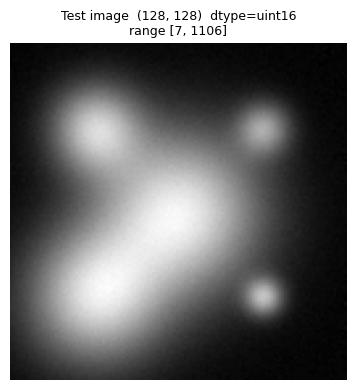

Total pixels: 16,384


In [3]:
def make_blobs(shape=(128, 128), seed=42):
    """Multi-scale Gaussian blobs on a noisy dark background."""
    rng = np.random.default_rng(seed)
    img = rng.normal(30, 8, shape).astype(np.float32)
    yy, xx = np.mgrid[:shape[0], :shape[1]]
    for cy, cx, sigma, amp in [
        (32, 32, 12, 800), (32, 96, 7, 600),
        (96, 32, 18, 900), (96, 96, 5, 700),
        (64, 64, 22, 1000),
    ]:
        img += amp * np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * sigma**2))
    return np.clip(img, 0, 65535).astype(np.uint16)


img = make_blobs()

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap='gray')
ax.set_title(
    f'Test image  {img.shape}  dtype={img.dtype}\n'
    f'range [{img.min()}, {img.max()}]'
)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Total pixels: {img.size:,}')


## 1. `rel_error` — reconstruction error tolerance

The central APR quality parameter. The APR guarantees that the constant
reconstruction deviates from the original by at most `rel_error` locally.

- **Lower** (e.g. 0.02) → more particles, higher fidelity
- **Higher** (e.g. 0.5) → fewer particles, higher compression

**Default: 0.1**


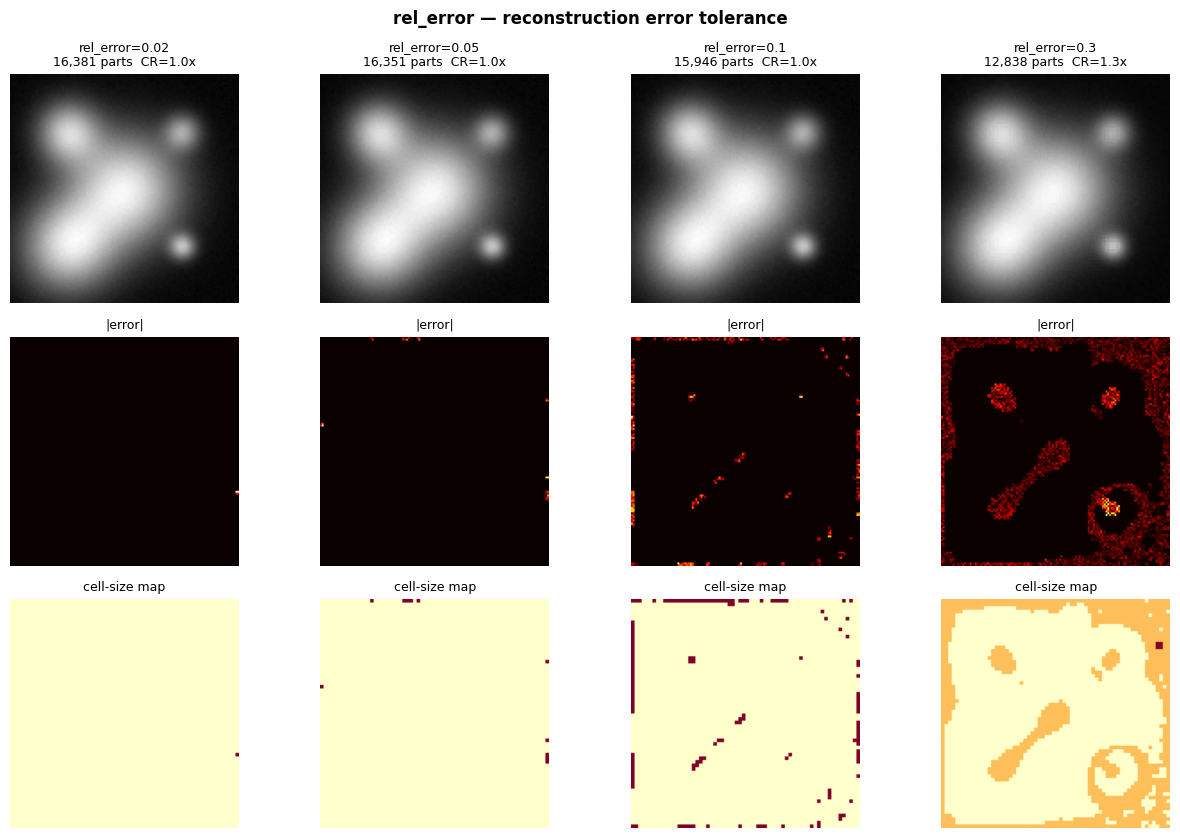

('rel_error=0.02', APR(shape [1, 128, 128], 16381 particles), ShortParticles(size 16381))
('rel_error=0.05', APR(shape [1, 128, 128], 16351 particles), ShortParticles(size 16351))
('rel_error=0.1', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('rel_error=0.3', APR(shape [1, 128, 128], 12838 particles), ShortParticles(size 12838))


In [4]:
values = [0.02, 0.05, 0.1, 0.3]
results = [(f'rel_error={v}', *get_apr_with(img, rel_error=v)) for v in values]
show_sweep(img, results, suptitle='rel_error — reconstruction error tolerance')
for f in results:
    print(f)

## 2. `gradient_smoothing` — B-spline pre-smoothing (λ)

Smoothing applied to the image before gradient estimation
(internally this is the λ parameter of the B-spline fit).

- **Low** (0–1): sharp gradient estimates → fine particles along edges
- **High** (>5): smoothed gradients → coarser particles even at transition zones

**Default: 3.0**


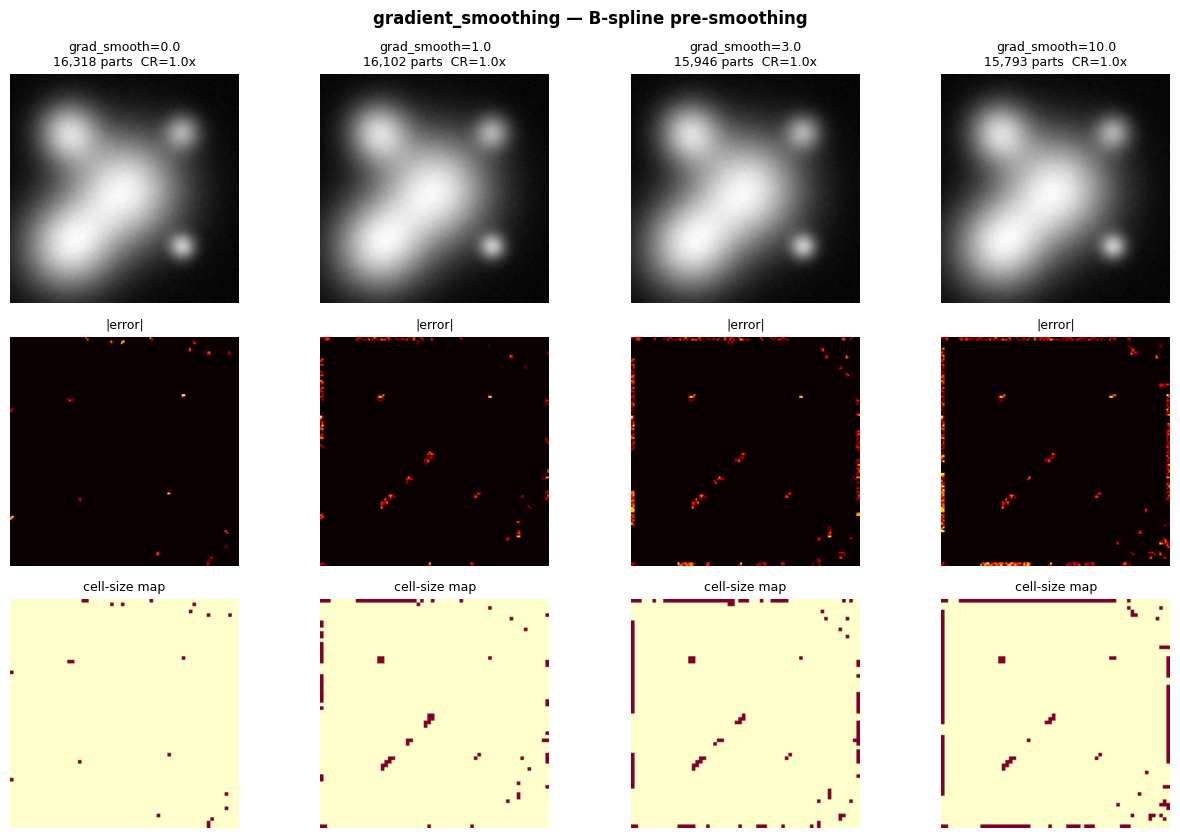

('grad_smooth=0.0', APR(shape [1, 128, 128], 16318 particles), ShortParticles(size 16318))
('grad_smooth=1.0', APR(shape [1, 128, 128], 16102 particles), ShortParticles(size 16102))
('grad_smooth=3.0', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('grad_smooth=10.0', APR(shape [1, 128, 128], 15793 particles), ShortParticles(size 15793))


In [5]:
values = [0.0, 1.0, 3.0, 10.0]
results = [(f'grad_smooth={v}', *get_apr_with(img, gradient_smoothing=v))
           for v in values]
show_sweep(img, results, suptitle='gradient_smoothing — B-spline pre-smoothing')
for f in results:
    print(f)

## 3. `Ip_th` — background intensity threshold

Pixels with intensity **below** `Ip_th` are treated as background and
assigned coarse (large) particles regardless of local gradient.
Useful for fluorescence images with a dark background.

**Default: 0** (no background suppression)


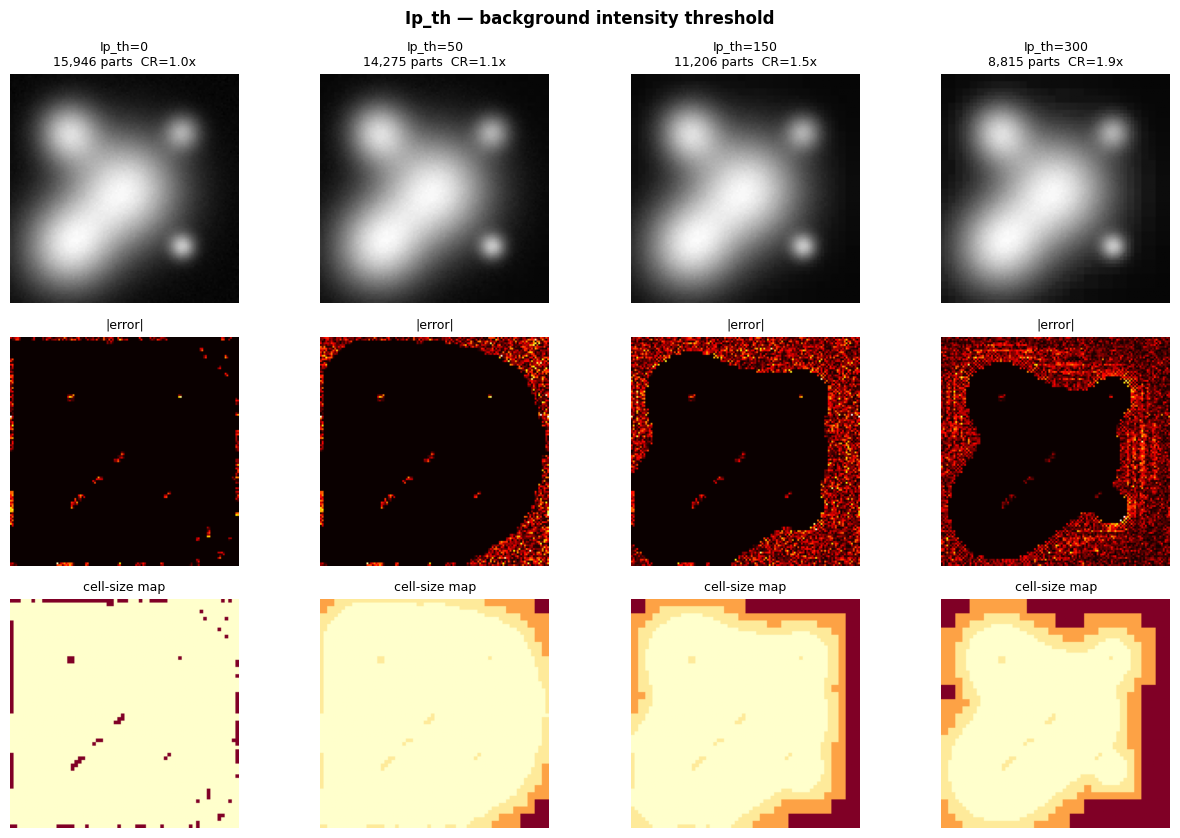

('Ip_th=0', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('Ip_th=50', APR(shape [1, 128, 128], 14275 particles), ShortParticles(size 14275))
('Ip_th=150', APR(shape [1, 128, 128], 11206 particles), ShortParticles(size 11206))
('Ip_th=300', APR(shape [1, 128, 128], 8815 particles), ShortParticles(size 8815))


In [6]:
values = [0, 50, 150, 300]
results = [(f'Ip_th={v}', *get_apr_with(img, Ip_th=v)) for v in values]
show_sweep(img, results, suptitle='Ip_th — background intensity threshold')
for f in results:
    print(f)

## 4. `sigma_th` — local intensity scale floor

The local intensity scale (LIS) estimates local signal strength.
`sigma_th` clamps the LIS from below: regions where LIS < `sigma_th`
are treated as low-signal and given coarser particles.

**Default: 0**


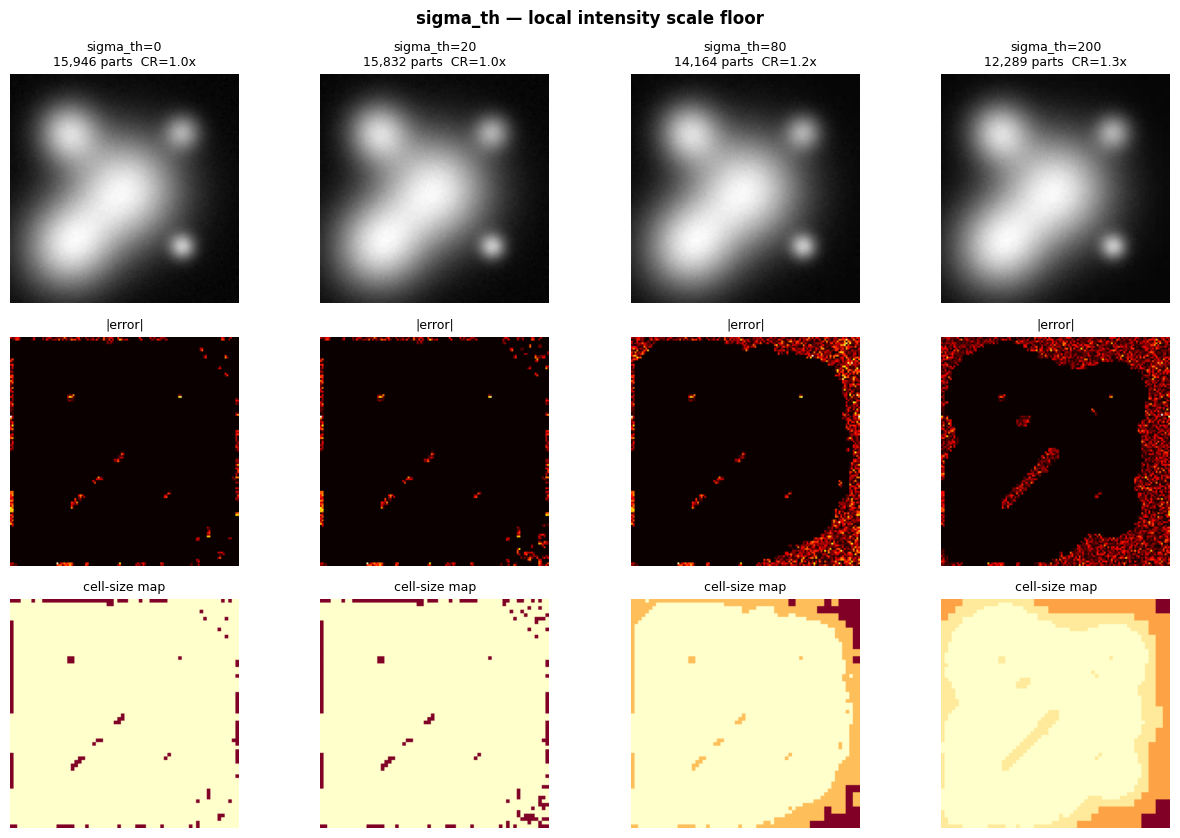

('sigma_th=0', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('sigma_th=20', APR(shape [1, 128, 128], 15832 particles), ShortParticles(size 15832))
('sigma_th=80', APR(shape [1, 128, 128], 14164 particles), ShortParticles(size 14164))
('sigma_th=200', APR(shape [1, 128, 128], 12289 particles), ShortParticles(size 12289))


In [7]:
values = [0, 20, 80, 200]
results = [(f'sigma_th={v}', *get_apr_with(img, sigma_th=v)) for v in values]
show_sweep(img, results, suptitle='sigma_th — local intensity scale floor')
for f in results:
    print(f)

## 5. `grad_th` — gradient magnitude floor

Gradient values below `grad_th` are zeroed out before computing
the particle resolution condition. This suppresses fine particles
in flat, slowly-varying regions.

**Default: 0**


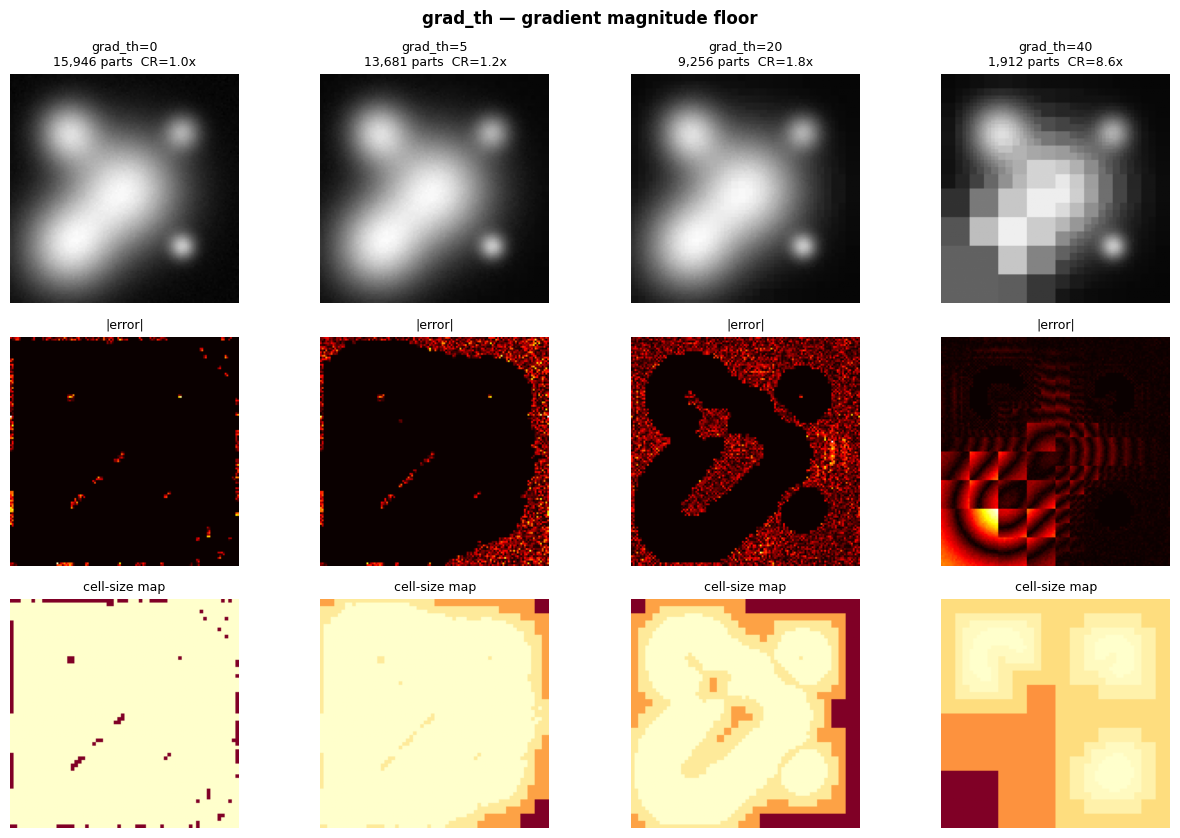

('grad_th=0', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('grad_th=5', APR(shape [1, 128, 128], 13681 particles), ShortParticles(size 13681))
('grad_th=20', APR(shape [1, 128, 128], 9256 particles), ShortParticles(size 9256))
('grad_th=40', APR(shape [1, 128, 128], 1912 particles), ShortParticles(size 1912))


In [8]:
values = [0, 5, 20, 40]
results = [(f'grad_th={v}', *get_apr_with(img, grad_th=v)) for v in values]
show_sweep(img, results, suptitle='grad_th — gradient magnitude floor')
for f in results:
    print(f)

## 6. `auto_parameters` — automatic threshold estimation

When `True`, `sigma_th` and `grad_th` are estimated automatically from
the image histogram using **Li's minimum cross-entropy thresholding**.
Good starting point without manual tuning.

**Default: False**


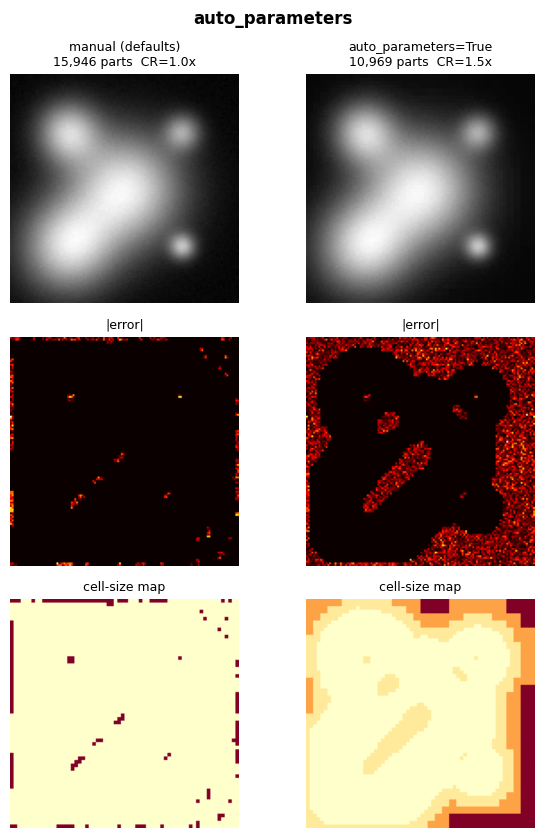

('manual (defaults)', APR(shape [1, 128, 128], 15946 particles), ShortParticles(size 15946))
('auto_parameters=True', APR(shape [1, 128, 128], 10969 particles), ShortParticles(size 10969))


In [9]:
manual_apr, manual_parts = get_apr_with(img)
auto_apr,   auto_parts   = get_apr_with(img, auto_parameters=True)

results = [
    ('manual (defaults)', manual_apr, manual_parts),
    ('auto_parameters=True', auto_apr, auto_parts),
]
show_sweep(img, results, suptitle='auto_parameters')
for f in results:
    print(f)

## 7. `psfx`, `psfy` — point spread function size

Controls the window used to estimate the local intensity scale (LIS).
Larger PSF → smoother LIS → generally coarser sampling.
Should match the actual optical PSF of the imaging system.

**Defaults: psfx=2, psfy=2**


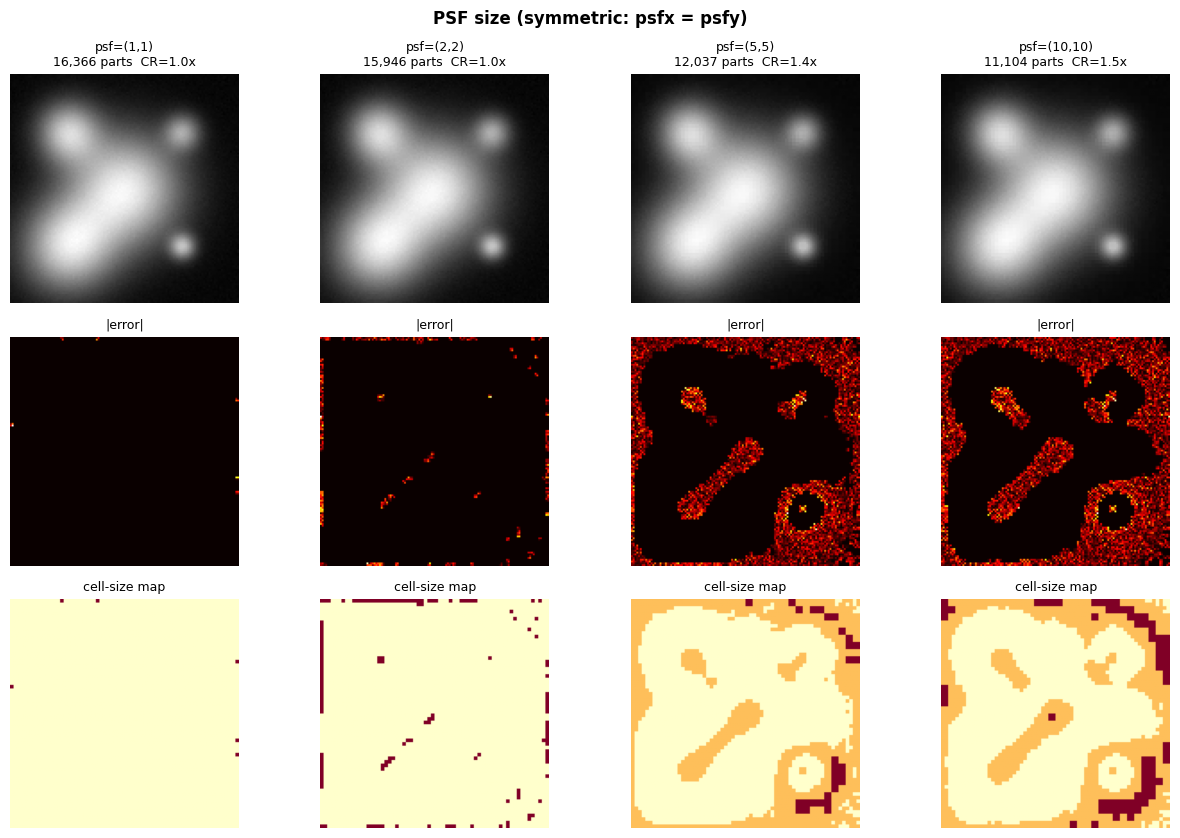

In [10]:
# Symmetric PSF: same size in x and y
configs = [(1, 1), (2, 2), (5, 5), (10, 10)]
results = [(f'psf=({px},{py})', *get_apr_with(img, psfx=px, psfy=py))
           for px, py in configs]
show_sweep(img, results, suptitle='PSF size (symmetric: psfx = psfy)')


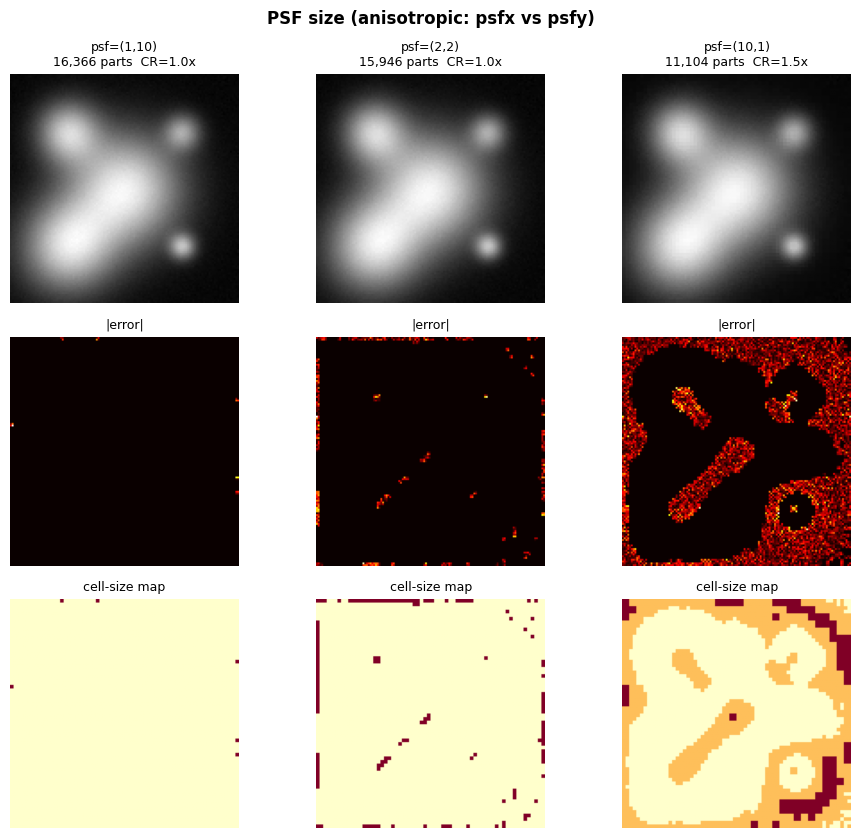

In [11]:
# Anisotropic PSF: different smoothing along x vs y
configs = [(1, 10), (2, 2), (10, 1)]
results = [(f'psf=({px},{py})', *get_apr_with(img, psfx=px, psfy=py))
           for px, py in configs]
show_sweep(img, results, suptitle='PSF size (anisotropic: psfx vs psfy)')


## 8. `dx`, `dy` — physical voxel size

Informs APR of the physical pixel size. When pixels represent different
physical extents in x vs y (anisotropic acquisition), set `dx ≠ dy` so
APR samples coarser in the direction with larger pixels.

**Defaults: dx=1, dy=1**

> **Note:** For 2D images, `dx` = row axis, `dy` = column axis.

The demo below uses `img[:, ::3]` — the isotropic blobs image downsampled
3× along columns (y). The correct setting is `dy=3`.


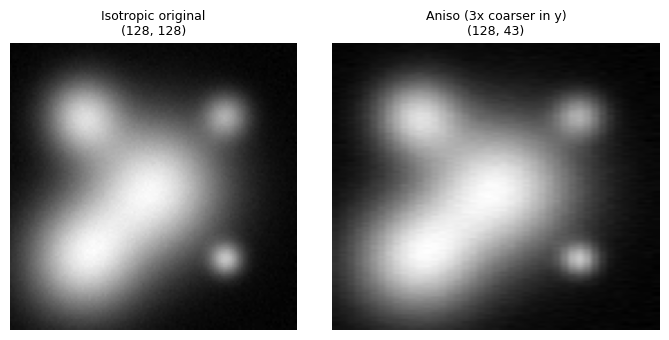

In [12]:
# Simulate anisotropy: take every 3rd column from the isotropic image
img_aniso = img[:, ::3]  # shape (128, 43) — y-pixels are 3x larger physically

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Isotropic original\n{img.shape}')
axes[0].axis('off')
axes[1].imshow(img_aniso, cmap='gray', aspect='auto')
axes[1].set_title(f'Aniso (3x coarser in y)\n{img_aniso.shape}')
axes[1].axis('off')
plt.tight_layout()
plt.show()


input image has been replaced with a C-contiguous copy of itself
input image has been replaced with a C-contiguous copy of itself


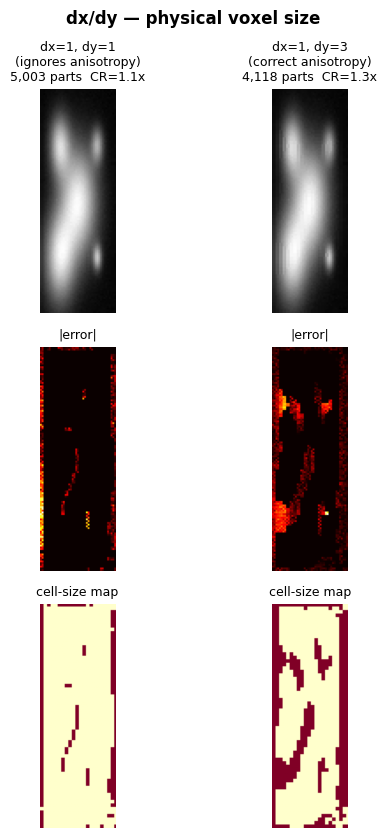

With dy=3: cell-size map should show larger cells along the y (column) axis.


In [13]:
results = [
    ('dx=1, dy=1\n(ignores anisotropy)', *get_apr_with(img_aniso, dx=1.0, dy=1.0)),
    ('dx=1, dy=3\n(correct anisotropy)', *get_apr_with(img_aniso, dx=1.0, dy=3.0)),
]
show_sweep(img_aniso, results, suptitle='dx/dy — physical voxel size')
print('With dy=3: cell-size map should show larger cells along the y (column) axis.')


## Summary

| Parameter | What it controls | Typical use |
|-----------|-----------------|-------------|
| `rel_error` | Primary quality/compression trade-off | Always tune first |
| `gradient_smoothing` | Sharpness of internal gradient estimates | 2–4 for most images |
| `Ip_th` | Background suppression | Dark-background fluorescence |
| `sigma_th` | Low-signal region coarsening | Low-SNR images |
| `grad_th` | Flat-region coarsening | Images with large uniform areas |
| `auto_parameters` | Auto-estimate `sigma_th` + `grad_th` | Good starting point |
| `psfx`, `psfy` | Local intensity scale window (match optical PSF) | Microscopy |
| `dx`, `dy` | Physical pixel size for anisotropic sampling | Anisotropic acquisitions |
